#### Correctvie RAG

In [27]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.environ.get("TAVILY_API_KEY")

In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

In [5]:
## create retriever 

urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api",
]

docs = [WebBaseLoader(url).load() for url in urls]

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

doc_splits = text_splitter.split_documents(docs_list)

# add all these to vector db

vectorstore = FAISS.from_documents(documents=doc_splits, embedding=OpenAIEmbeddings())

retriever = vectorstore.as_retriever()

In [6]:
## retrieval grader

from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


class grade(BaseModel):
    """Binary score for relevance check."""

    binary_score: str = Field(description="Relevance score 'yes' or 'no'")


llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tool = llm.with_structured_output(grade)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# Chain
retrieval_grader = prompt | llm_with_tool
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='no'


In [7]:
## generate node
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = PromptTemplate(
    template="""You are a agent who gives the relevant answer based on the input. \n 
    Here is the retrieved document: \n\n {context} \n\n
    Here is the user question: {question} \n
    """,
    input_variables=["context", "question"],
)

# LLM
llm = ChatGroq(model="qwen/qwen3-32b")

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
response = rag_chain.invoke({"context": docs, "question": question})
print(response)

<think>
Okay, the user is asking about "agent memory." Let me look through the provided documents to find relevant information.

First, in the document with ID '02cdd2ee-b65b-4945-947a-f833ceb68283', there's a mention of "Comprehensive memory: Create stateful agents with both short-term working memory for ongoing reasoning and long-term memory across sessions." That seems directly related. So LangGraph allows agents to have both short-term and long-term memory.

Another document, '3ebd2e33-3c76-4deb-a070-03cb97224af7', has a section titled "Memory" under "Workflows and agents." It probably goes into more details about how memory is implemented. Also, there's a mention of "Time travel" under "Capabilities" which might relate to memory states over time.

The user might be interested in how agents retain information during and between sessions. The first document explains durable execution and stateful agents, which ties into memory persistence. Also, "Debugging with LangSmith" mentions t

In [8]:
## rewrite node

# Prompt
prompt = PromptTemplate(
    template="""You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the user question: {question} \n
    """,
    input_variables=["question"],
)

# LLM
llm = ChatGroq(model="qwen/qwen3-32b")

# Chain
question_rewriter = prompt | llm | StrOutputParser()

# Run
response = question_rewriter.invoke({"question": question})
print(response)

<think>
Okay, the user asked "agent memory". Let me start by understanding what they really need. The term "agent memory" is pretty broad. It could refer to different things depending on the context. Maybe they're talking about AI agents and how they retain information? Or perhaps it's about software agents in computing? Or even something related to espionage, like agent memory in a spy context?

First, I need to consider the most common contexts. In AI, an agent's memory might relate to how it stores past experiences to improve future decisions. That's a big field right now with machine learning models. So the user might be looking for information on AI agent memory systems, like how they use memory networks or long-term memory in reinforcement learning.

Alternatively, in software engineering, an agent could be a type of program that performs tasks, and memory here might be about how these agents manage data or state. But that's less likely. Another angle could be user agents in web 

In [38]:
## tavily search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)
web_search_tool.invoke({"query": "What are the IPL standings in 2026"})

[{'title': 'IPL 2026 Points Table: IPL Team Standings, IPL Rankings and Net ...',
  'url': 'https://timesofindia.indiatimes.com/sports/cricket/ipl/points-table',
  'content': ', and boast the best net run rate in the league at +1.065, making them one of the most dominant sides.  \n  \nGujarat Titans are second in the points table with 16 points from 13 matches, having won 8 and lost 5, along with a net run rate of +0.400, giving them a strong hold on the playoff race. Sunrisers Hyderabad are third with 16 points from 13 matches, winning 8 and losing 5, with an NRR of +0.350.  \n  \nPunjab Kings are fourth with 13 points from 13 matches (6 wins, 6 losses, 1 no result) and a net run rate of +0.227, keeping them just in contention. Rajasthan Royals and Chennai Super Kings are placed fifth and sixth respectively, both on 12 points but RR have a better NRR in comparison. CSK have played 13 games, while RR have played 12 games. [...] Delhi Capitals sit seventh with 12 points from 13 matches,

In [29]:
## Create the state

from typing_extensions import TypedDict
from typing import List


class State(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [ ]:
## create all the nodes


def retrieve(state: State):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def grade_documents(state: State):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def generate(state: State):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def transform_query(state: State):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


from langchain_core.documents import Document


def web_search(state: State):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

# conditional edge
def decide_to_generate(state: State):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [32]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(State)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

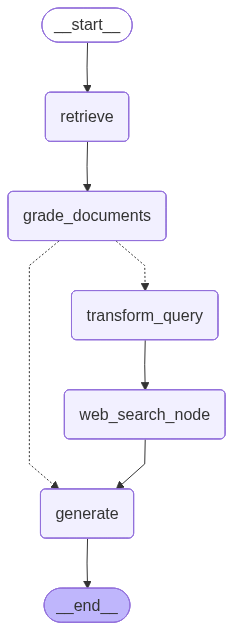

In [33]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [36]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---


TypeError: string indices must be integers, not 'str'